In [30]:
import pandas as pd
import glob
import os

# Ищем все CSV‑файлы в текущей директории
period_timeframe = '1d_last_year'
file_paths = glob.glob(f"data/{period_timeframe}/*.csv")

# Словарь для хранения цен закрытия по каждой криптовалюте
close_prices = {}

for file_path in file_paths:
    # Извлекаем имя криптовалюты из имени файла (без расширения)
    crypto_name = os.path.splitext(os.path.basename(file_path))[0]

    # Загружаем датасет
    df = pd.read_csv(file_path)

    # Проверяем наличие столбца 'close' (возможны варианты написания)
    if 'close' in df.columns:
        close_prices[crypto_name] = df['close']
    elif 'Close' in df.columns:
        close_prices[crypto_name] = df['Close']
    else:
        print(f"Предупреждение: в файле {file_path} нет столбца 'close' или 'Close'")

# Создаём DataFrame, где колонки — криптовалюты, строки — даты/индексы
prices_df = pd.DataFrame(close_prices)


In [31]:
prices_df

,2ZUSDT_1d_last_year,AAVEUSDT_1d_last_year,ADAUSDT_1d_last_year,ALGOUSDT_1d_last_year,APTUSDT_1d_last_year,ARBUSDT_1d_last_year,ASTERUSDT_1d_last_year,ATOMUSDT_1d_last_year,AVAXUSDT_1d_last_year,BCHUSDT_1d_last_year,...,WIFUSDT_1d_last_year,WLDUSDT_1d_last_year,WLFIUSDT_1d_last_year,XAUTUSDT_1d_last_year,XLMUSDT_1d_last_year,XPLUSDT_1d_last_year,XRPUSDT_1d_last_year,XTZUSDT_1d_last_year,ZECUSDT_1d_last_year,ZROUSDT_1d_last_year
0,0.59800,143.15,0.6315,0.1802,4.732,0.2934,2.063,4.537,18.44,301.4,...,0.372,0.7100,0.2335,4406.39,0.2422,1.2773,2.0529,0.6050,36.45,2.621
1,0.52205,131.95,0.6094,0.1766,4.614,0.2863,2.045,4.336,18.31,289.8,...,0.366,0.6940,0.2271,4494.53,0.2303,1.2219,1.9658,0.5430,36.29,2.411
2,0.49652,136.49,0.6239,0.1797,4.788,0.2950,1.928,4.246,19.12,312.9,...,0.396,0.7400,0.2173,4488.26,0.2339,1.6290,2.0225,0.5430,35.39,2.549
3,0.49129,148.10,0.6595,0.1911,4.964,0.3110,1.681,4.352,20.49,344.7,...,0.468,0.7810,0.1867,4447.52,0.2463,1.4519,2.1598,0.5580,34.83,2.656
4,0.49564,139.18,0.6383,0.1829,4.825,0.3005,1.321,4.147,19.59,342.8,...,0.445,0.7430,0.1812,4505.71,0.2380,1.1985,2.1196,0.5040,31.04,2.413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,NaN,94.48,0.2479,0.1205,0.850,0.0927,NaN,1.713,8.99,441.2,...,0.181,0.2577,NaN,NaN,0.1619,NaN,1.3153,0.3486,251.14,1.915
361,NaN,94.14,0.2508,0.1215,0.850,0.0942,NaN,1.698,9.06,428.6,...,0.182,0.2489,NaN,NaN,0.1627,NaN,1.3263,0.3449,245.08,1.859
362,NaN,93.00,0.2461,0.1186,0.839,0.0937,NaN,1.703,8.91,435.1,...,0.178,0.2431,NaN,NaN,0.1557,NaN,1.3212,0.3415,251.54,1.773
363,NaN,95.79,0.2627,0.1171,0.872,0.1019,NaN,1.807,9.43,445.9,...,0.199,0.2704,NaN,NaN,0.1635,NaN,1.3787,0.3612,320.78,2.088


In [32]:
start_dates = {}
for col in prices_df.columns:
    # Ищем первый не-NaN индекс
    first_valid = prices_df[col].first_valid_index()
    start_dates[col] = first_valid

In [33]:
common_start = max(start_dates.values())
prices_common = prices_df.loc[common_start:].copy()

In [34]:
prices_clean = prices_common.dropna(axis=1)  # Удаляем монеты без данных в общем периоде

In [35]:
# Матрица корреляции Пирсона (по умолчанию)
correlation_matrix = prices_clean.corr(method='pearson')

# Другие методы (при необходимости):
# Спирмена (для монотонных зависимостей, устойчивее к выбросам)
# correlation_matrix = prices_df_clean.corr(method='spearman')
# Кендалла (ранговая корреляция)
# correlation_matrix = prices_df_clean.corr(method='kendall')


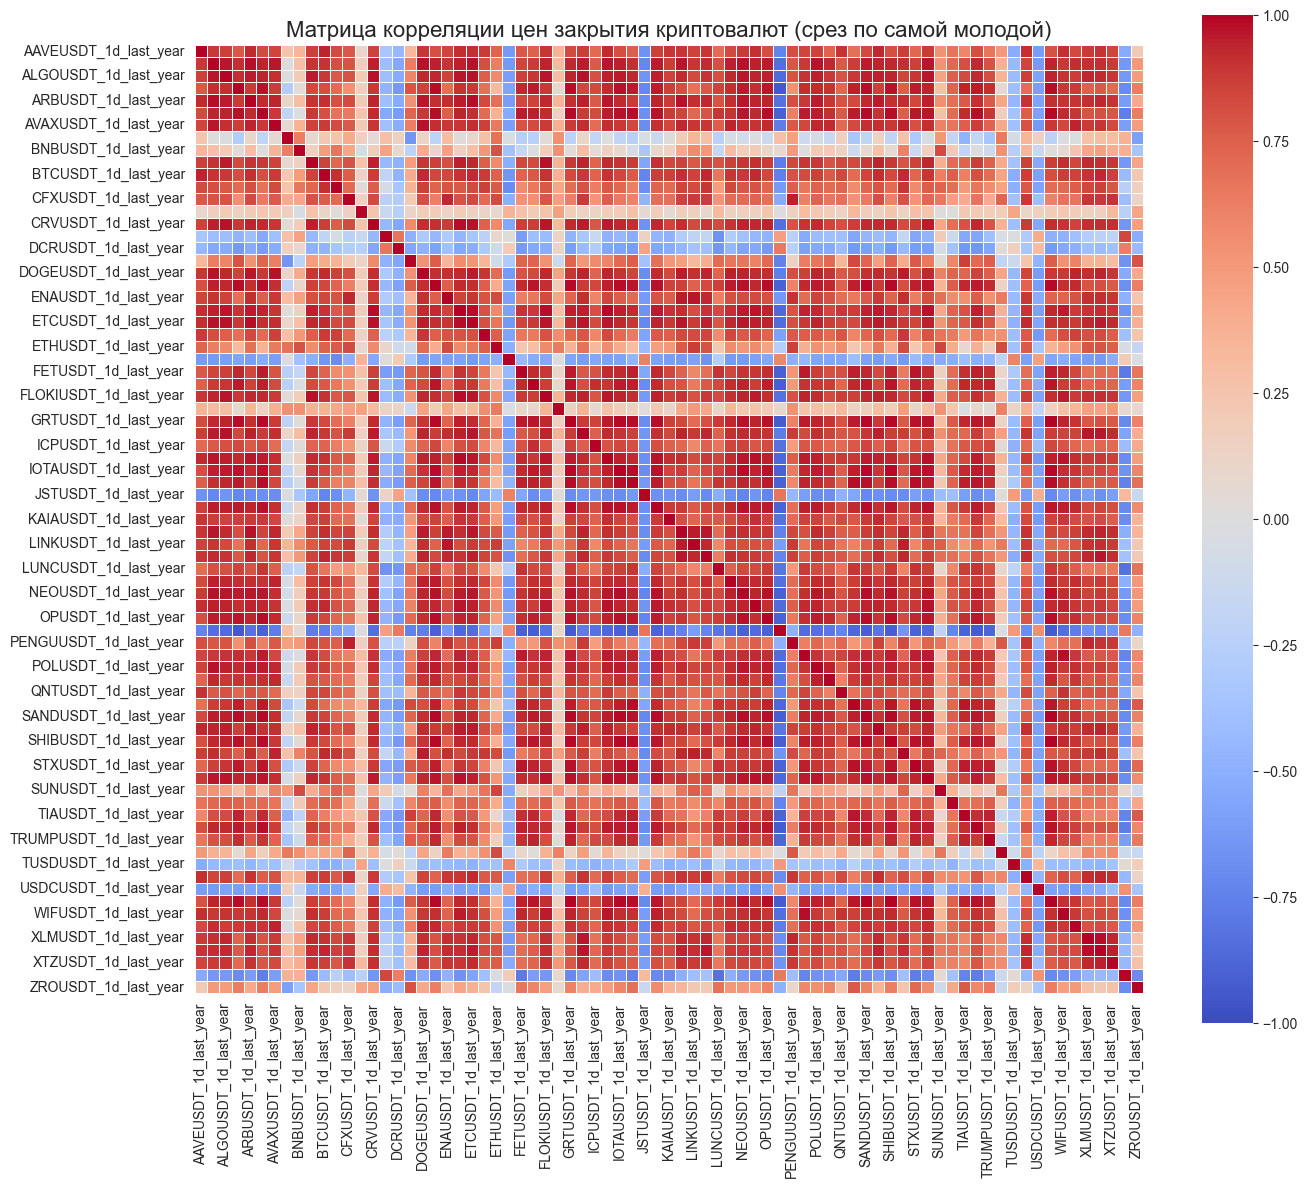

Матрица сохранена как 'correlation_matrix.png'


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    #mask=mask,
    annot=False,           # Показывать значения в ячейках
    cmap='coolwarm',       # Цветовая схема: красный — положительная, синий — отрицательная
    vmin=-1, vmax=1,   # Диапазон значений корреляции
    center=0,           # Центр цветовой шкалы
    square=True,         # Квадратные ячейки
    linewidths=0.5,     # Толщина линий между ячейками
    fmt='.2f'           # Формат чисел (2 знака после запятой)
)
plt.title('Матрица корреляции цен закрытия криптовалют (срез по самой молодой)', fontsize=16)
plt.tight_layout()

# Сохраняем как картинку
plt.savefig(f'plots/correlation_matrix{period_timeframe}.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()  # Закрываем фигуру, чтобы освободить память
print("Матрица сохранена как 'correlation_matrix.png'")


